In [82]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

# from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings, ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import SystemMessage, HumanMessage

# 
from langchain_core.output_parsers import PydanticOutputParser

In [83]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [84]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [85]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [86]:
llm1 = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    # repo_id="LiquidAI/LFM2.5-230M",
    task="text-generation",
)
llm = ChatHuggingFace(llm=llm1)

In [87]:
parser = PydanticOutputParser(pydantic_object=Plan)

In [88]:
def orchestrator(state: State) -> dict:

    prompt = f"""
Create a blog plan with 5-7 sections on the following topic.

Topic: {state['topic']}

{parser.get_format_instructions()}
"""

    response = llm.invoke(
        [
            SystemMessage(
                content="You are a professional blog planning assistant."
            ),
            HumanMessage(content=prompt),
        ]
    )

    # Convert LLM text output into Plan object
    plan = parser.parse(response.content)
    
    return {"plan": plan}

# def orchestrator(state: State) -> dict:

#     plan = llm.with_structured_output(Plan).invoke(
#         [
#             SystemMessage(
#                 content=(
#                     "Create a blog plan with 5-7 sections on the following topic."
#                 )
#             ),
#             HumanMessage(content=f"Topic: {state['topic']}"),
#         ]
#     )
#     return {"plan": plan}

In [89]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

# For example, Worker 2 might receive:
# {
#     "task": Task(
#         id=2,
#         title="Query, Key and Value",
#         brief="Explain Q, K and V"
#     ),

#     "topic": "Self Attention",

#     "plan": Plan(...)
# }

In [90]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [91]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [92]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

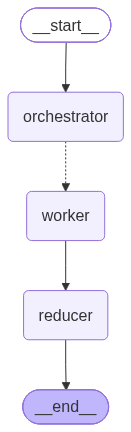

In [93]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [94]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

HfHubHTTPError: 402 Client Error: Payment Required for url: https://router.huggingface.co/featherless-ai/v1/chat/completions (Request ID: Root=1-6a91bf6e-17da1f6b0b586e2442464a24;0829b13a-2f5a-40db-8150-2d573ddffdca)

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.